## Step 2: Dataset Loading & Exploratory Data Analysis

### 2.1  Load & Understand the Dataset

In [15]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('dataset/house_dataset.csv')

In [7]:
print(df.shape)

(1460, 81)


#### Identify: 
* how many numerical columns
* how many categorical columns 
* how many columns have missing values

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [58]:
num_cols = df.select_dtypes(exclude='object').columns
cat_cols = df.select_dtypes(include='object').columns

print(f'Total Numerical columns in this dataset: \n{len(num_cols)}')
print('='*45)
print(f'Total Categorical columns in this dataset: \n{len(cat_cols)}')
print('='*45)
print('Total columns with Missing Values:')
print((df.isna().sum() > 0).values.sum())

Total Numerical columns in this dataset: 
38
Total Categorical columns in this dataset: 
43
Total columns with Missing Values:
19


#### Plot a histogram of the target variable SalePrice

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

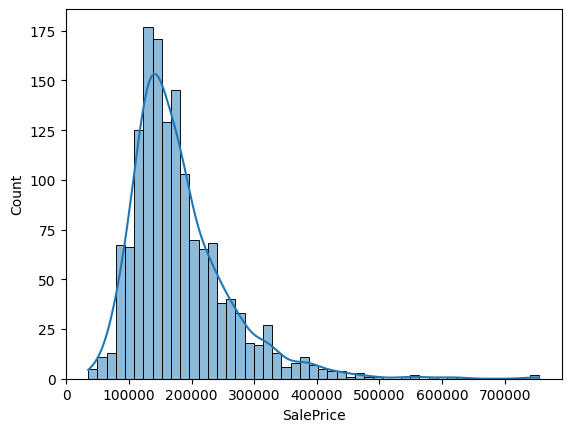

In [12]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

This data is not normally distributed so we will apply log1p transformation.

#### Apply log1p transformation and re-plot.

In [16]:
df['SalePrice'] = np.log1p(df['SalePrice'])

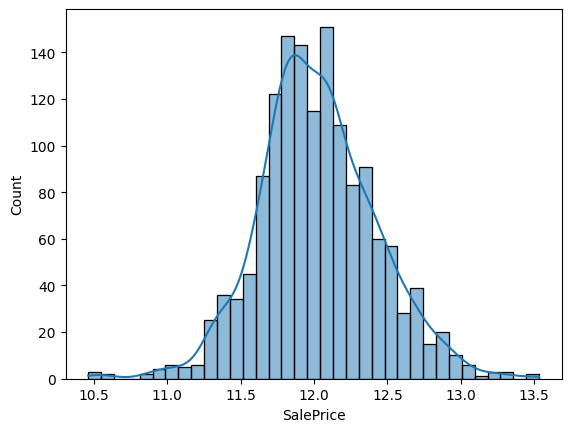

In [17]:
sns.histplot(df['SalePrice'], kde=True)
plt.show()

### 2.2  Univariate Analysis

#### Identify the top 5 most skewed columns

In [62]:
skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print(skewness.head(5))

MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


#### Plot countplot for high-impact categorical column

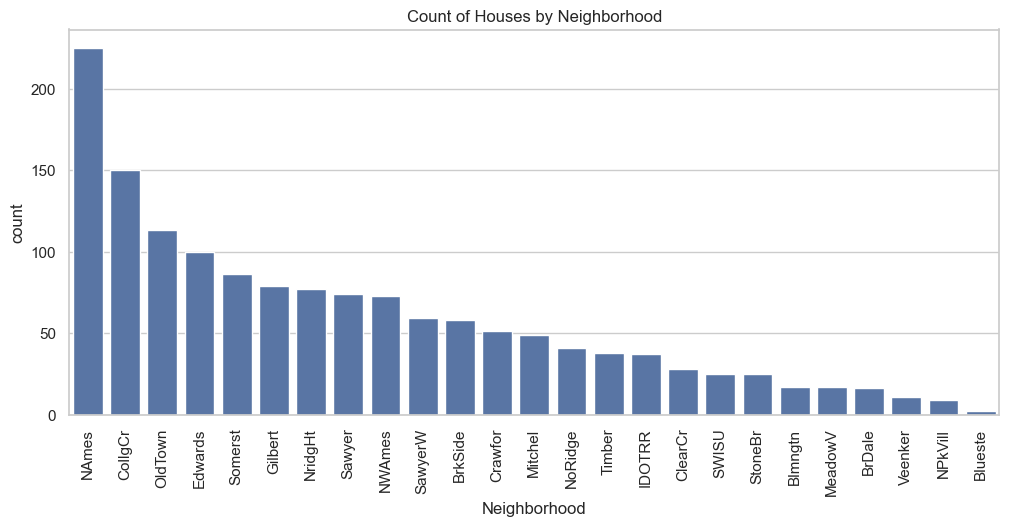

In [67]:
plt.figure(figsize=(12,5))
sns.countplot(x='Neighborhood', data=df, order=df['Neighborhood'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Count of Houses by Neighborhood")
plt.show()

### 2.3  Bivariate Analysis

#### Plot a heatmap of the top 15 features most correlated with SalePrice

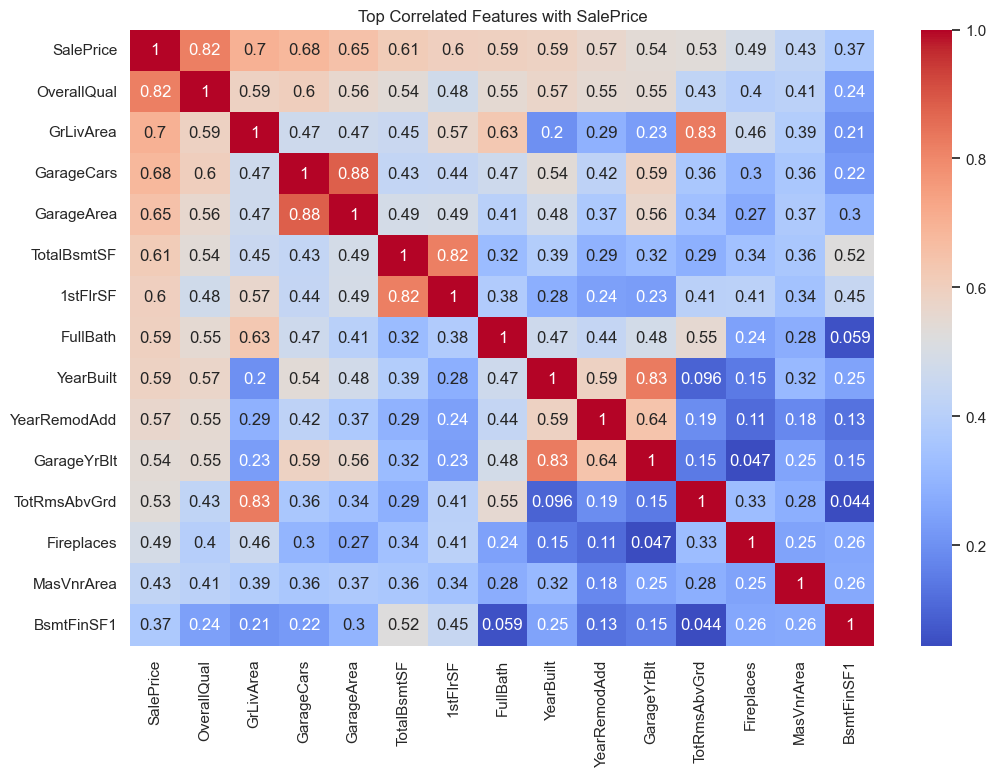

In [66]:
#  Correlation Heatmap (Top features)
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

# Select top 15 correlated with SalePrice
top_corr = corr['SalePrice'].sort_values(ascending=False).head(15)

sns.heatmap(df[top_corr.index].corr(), annot=True, cmap="coolwarm")
plt.title("Top Correlated Features with SalePrice")
plt.show()

#### Scatter plot

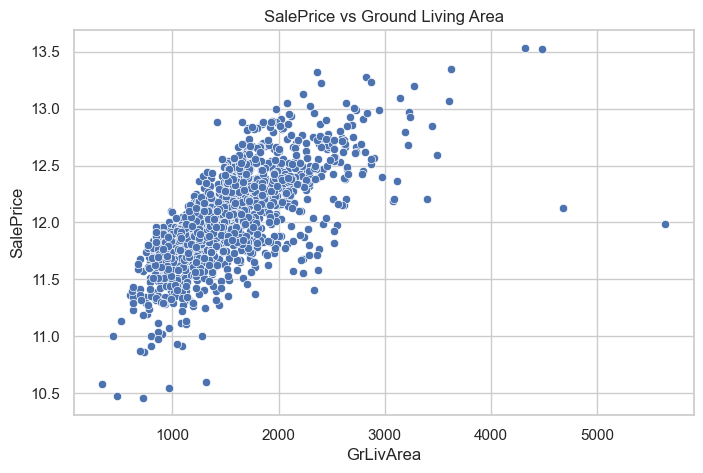

In [70]:
# SalePrice vs Living Area
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("SalePrice vs Ground Living Area")
plt.show()

## Step 3: Data Preprocessing & Feature Engineering

#### Report all columns with missing values and their missing %.

In [103]:
missing_percentage = ((df.isna().sum() / len(df)) * 100).round(2)
print(missing_percentage[missing_percentage > 0])

LotFrontage     17.74
Alley           93.77
MasVnrType      59.73
MasVnrArea       0.55
BsmtQual         2.53
BsmtCond         2.53
BsmtExposure     2.60
BsmtFinType1     2.53
BsmtFinType2     2.60
Electrical       0.07
FireplaceQu     47.26
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
PoolQC          99.52
Fence           80.75
MiscFeature     96.30
dtype: float64


#### Drop columns with >80% missing values

In [106]:
df.drop(missing_percentage[missing_percentage > 80].index,axis=1,inplace=True)

#### For categorical columns fill missing with 'None'